c:\Users\malik\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


  ï»¿Class                                            Message
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
3      ham  U dun say so early hor... U c already then say...
4      ham  Nah I don't think he goes to usf, he lives aro...
Index(['ï»¿Class', 'Message'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5574 entries, 0 to 5573
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   ï»¿Class  5574 non-null   object
 1   Message   5574 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None
label
ham     4827
spam     747
Name: count, dtype: int64
count    5571.000000
mean       74.049542
std        54.933821
min         2.000000
25%        33.000000
50%        57.000000
75%       112.000000
max       888.000000
Name: msg_length, dtype: float64
حجم القاموس: 7558


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 12s 69ms/step - accuracy: 0.9217 - loss: 0.2309 - val_accuracy: 0.9843 - val_loss: 0.0565
Epoch 2/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 79ms/step - accuracy: 0.9854 - loss: 0.0614 - val_accuracy: 0.9877 - val_loss: 0.0491
Epoch 3/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - accuracy: 0.9927 - loss: 0.0310 - val_accuracy: 0.9854 - val_loss: 0.0619
Epoch 4/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 8s 69ms/step - accuracy: 0.9955 - loss: 0.0158 - val_accuracy: 0.9865 - val_loss: 0.0533
Epoch 5/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 8s 74ms/step - accuracy: 0.9992 - loss: 0.0065 - val_accuracy: 0.9877 - val_loss: 0.0639
Epoch 6/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 80ms/step - accuracy: 0.9980 - loss: 0.0090 - val_accuracy: 0.9854 - val_loss: 0.0824
Epoch 7/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - accuracy: 0.9994 - loss: 0.0040 - val_accuracy: 0.9899 - val_loss: 0.0838

[5] تقييم النماذج...

--- نتائج LSTM ---
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step

Dقة النم

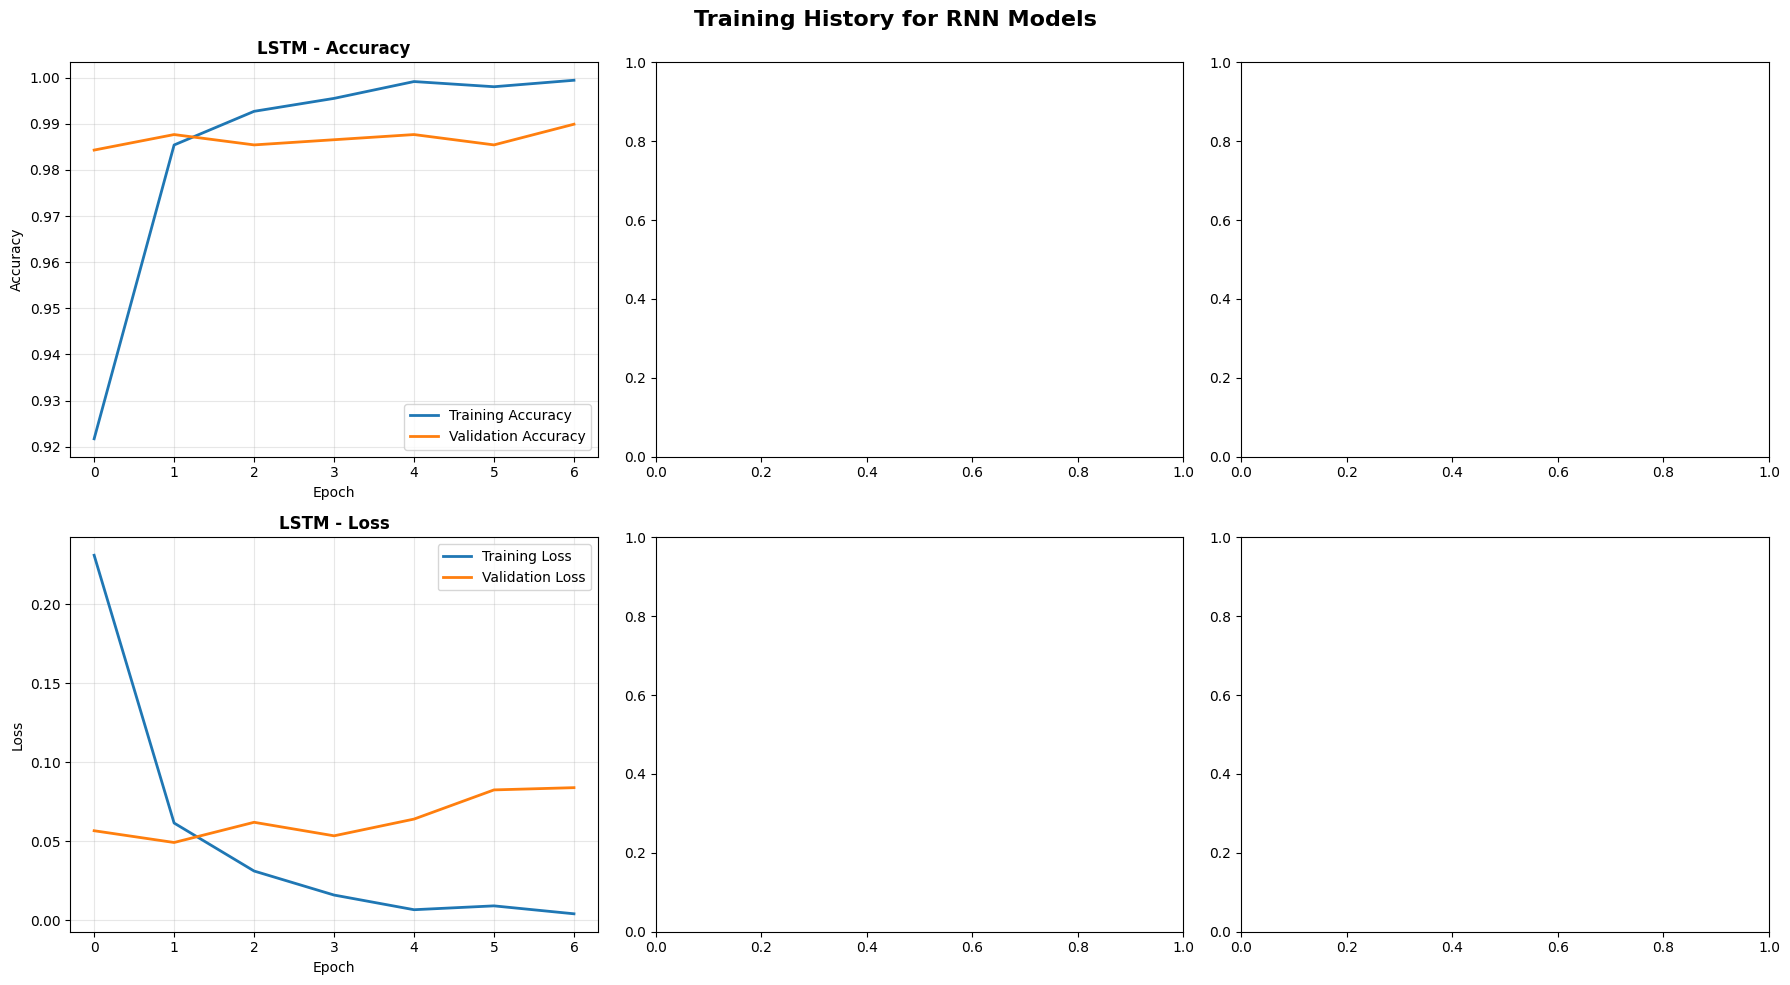

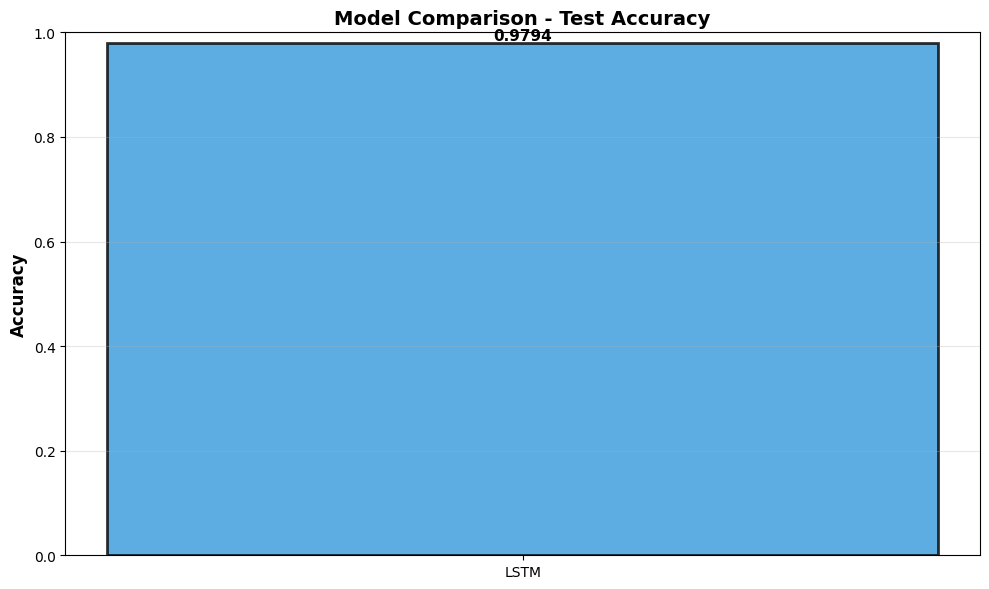

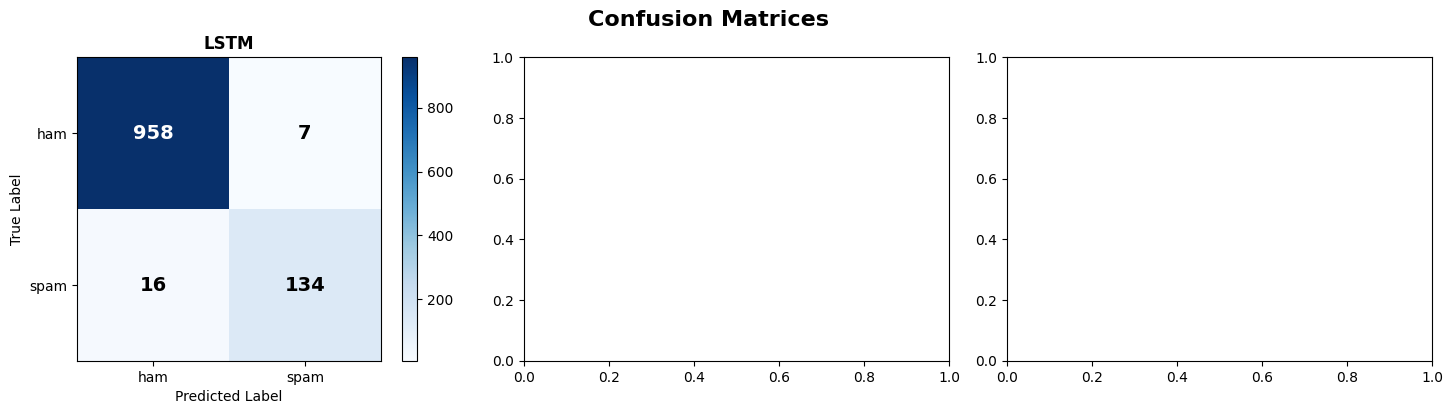

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,LSTM,Dropout,Bidirectional,Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Input
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings('ignore')
df=pd.read_csv('Spam_SMS.csv',encoding='latin-1')
print(df.head())
print(df.columns)
print(df.info())
df = df[['ï»¿Class', 'Message']]
df.columns = ['label', 'message']
label_counts = df['label'].value_counts()
print(label_counts)

# الاحتفاظ بالرموز المهمة (!, $, %) مع الحروف والمسافات
df['message'] = df['message'].str.replace(r"[^a-zA-Z\s!$%]", "", regex=True).str.lower()
df = df[df['message'].str.strip() != ""]

df['msg_length'] = df['message'].apply(len)
print(df['msg_length'].describe())

df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

X = df['message']
y = df['label_num']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)




max_words = 5000
max_len = 120
EMBEDDING_DIM = 128

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)


# تحويل النصوص إلى تسلسلات
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Padding
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

print(f"حجم القاموس: {len(tokenizer.word_index)}")
print(f"شكل بيانات التدريب: {X_train_pad.shape}")

# بناء نموذج LSTM
def build_lstm():
    """بناء نموذج LSTM"""
    model = Sequential([
        Embedding(input_dim=max_words, output_dim=EMBEDDING_DIM, input_length=max_len),
        Bidirectional(LSTM(64, return_sequences=False   )),
        Dropout(0.5),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

EPOCHS = 20
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.2

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# قاموس لحفظ النماذج والنتائج
models = {}
histories = {}


class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)





print("\n--- تدريب LSTM ---")
model_lstm = build_lstm()
print(model_lstm.summary())

history_lstm = model_lstm.fit(
    X_train_pad, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    callbacks=[early_stop],
    verbose=1
)

models['LSTM'] = model_lstm
histories['LSTM'] = history_lstm


# ============================================
# 5. تقييم النماذج
# ============================================
print("\n[5] تقييم النماذج...")
print("="*70)

results = {}

for name, model in models.items():
    print(f"\n--- نتائج {name} ---")

    # التنبؤ
    
    y_pred_prob = model.predict(X_test_pad)
    threshold = 0.35

    y_pred = (y_pred_prob > threshold).astype(int).flatten()

    # حساب الدقة
    accuracy = accuracy_score(y_test, y_pred)

    # تقرير التصنيف
    print(f"\nDقة النموذج: {accuracy:.4f}")
    print("\nتقرير التصنيف:")
    print(classification_report(y_test, y_pred, target_names=['ham', 'spam']))

    # مصفوفة الارتباك
    cm = confusion_matrix(y_test, y_pred)
    print("\nمصفوفة الارتباك:")
    print(cm)
    # حفظ النتائج
    results[name] = {
        'accuracy': accuracy,
        'predictions': y_pred,
        'confusion_matrix': cm
    }    






# رسم منحنيات التدريب
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Training History for RNN Models', fontsize=16, fontweight='bold')

for idx, (name, history) in enumerate(histories.items()):
    # رسم الدقة
    axes[0, idx].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    if 'val_accuracy' in history.history:
        axes[0, idx].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    axes[0, idx].set_title(f'{name} - Accuracy', fontsize=12, fontweight='bold')
    axes[0, idx].set_xlabel('Epoch')
    axes[0, idx].set_ylabel('Accuracy')
    axes[0, idx].legend()
    axes[0, idx].grid(True, alpha=0.3)

    # رسم الخسارة
    axes[1, idx].plot(history.history['loss'], label='Training Loss', linewidth=2)
    if 'val_loss' in history.history:
        axes[1, idx].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[1, idx].set_title(f'{name} - Loss', fontsize=12, fontweight='bold')
    axes[1, idx].set_xlabel('Epoch')
    axes[1, idx].set_ylabel('Loss')
    axes[1, idx].legend()
    axes[1, idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
print("تم حفظ الرسم: training_history.png")

# رسم مقارنة الدقة
fig, ax = plt.subplots(figsize=(10, 6))
model_names = list(results.keys())
accuracies = [results[name]['accuracy'] for name in model_names]

bars = ax.bar(model_names, accuracies, color=['#3498db', '#e74c3c', '#2ecc71'], alpha=0.8, edgecolor='black', linewidth=2)
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Model Comparison - Test Accuracy', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1])
ax.grid(True, axis='y', alpha=0.3)

# إضافة القيم فوق الأعمدة
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
print("تم حفظ الرسم: model_comparison.png")

# رسم مصفوفات الارتباك
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Confusion Matrices', fontsize=16, fontweight='bold')

for idx, (name, result) in enumerate(results.items()):
    cm = result['confusion_matrix']
    im = axes[idx].imshow(cm, interpolation='nearest', cmap='Blues')
    axes[idx].set_title(f'{name}', fontsize=12, fontweight='bold')

    # إضافة colorbar
    plt.colorbar(im, ax=axes[idx])

    # إضافة التسميات
    axes[idx].set_xticks([0, 1])
    axes[idx].set_yticks([0, 1])
    axes[idx].set_xticklabels(['ham', 'spam'])
    axes[idx].set_yticklabels(['ham', 'spam'])
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

    # إضافة الأرقام داخل المصفوفة
    for i in range(2):
        for j in range(2):
            text = axes[idx].text(j, i, cm[i, j],
                                ha="center", va="center", color="white" if cm[i, j] > cm.max()/2 else "black",
                                fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
print("تم حفظ الرسم: confusion_matrices.png")

print("\nتم الانتهاء من جميع العمليات بنجاح.")

print("\n[7] اختبار النماذج على أمثلة جديدة...")
print("="*70)

test_sentences = [
    "This is an amazing and wonderful movie!",
    "Terrible film, waste of time and money.",
    "I absolutely loved it! Best movie ever!",
    "Boring and disappointing. Would not recommend.",
    "Great performances and excellent direction."
]

print("\nاختبار النماذج على جمل جديدة:\n")

for sentence in test_sentences:
    print(f"\nالجملة: {sentence}")

    # تحويل الجملة
    seq = tokenizer.texts_to_sequences([sentence])
    padded = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')

    # التنبؤ باستخدام كل نموذج
    for name, model in models.items():
        pred_prob = model.predict(padded, verbose=0)[0][0]
        sentiment = "spam" if pred_prob > 0.5 else "ham"
        print(f"  {name}: {sentiment} (احتمالية: {pred_prob:.4f})")

print("\n[7] اختبار النموذج على رسائل جديدة...")
print("="*70)

test_messages = [
    "Congratulations! You won a free iPhone. Click here now!",
    "Hey, are we meeting tomorrow at 5pm?",
    "URGENT! Your account has been suspended. Verify immediately.",
    "Can you send me the notes for today's lecture?",
    "WIN CASH NOW!!! Call this number to claim your prize."
]

print("\nاختبار النموذج على رسائل جديدة:\n")
for msg in test_messages:
    print(f"\nالرسالة: {msg}")
    msg_clean = ''.join([c.lower() for c in msg if c.isalpha() or c.isspace()])
    seq = tokenizer.texts_to_sequences([msg_clean])
    padded = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')
    
    pred_prob = model_lstm.predict(padded, verbose=0)[0][0]
    result = "spam" if pred_prob > threshold else "ham"  # استخدم threshold محسّن
    print(f"التصنيف: {result} (احتمالية: {pred_prob:.4f})")

  ï»¿Class                                            Message
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
3      ham  U dun say so early hor... U c already then say...
4      ham  Nah I don't think he goes to usf, he lives aro...
Index(['ï»¿Class', 'Message'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5574 entries, 0 to 5573
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   ï»¿Class  5574 non-null   object
 1   Message   5574 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None
label
ham     4827
spam     747
Name: count, dtype: int64
count    5571.000000
mean       74.049542
std        54.933821
min         2.000000
25%        33.000000
50%        57.000000
75%       112.000000
max       888.000000
Name: msg_length, dtype: float64
حجم القاموس: 7558


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 120, 128)       │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 742,977 (2.83 MB)

 Trainable params: 742,977 (2.83 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 12s 64ms/step - accuracy: 0.9158 - loss: 0.2472 - val_accuracy: 0.9832 - val_loss: 0.0604
Epoch 2/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.9865 - loss: 0.0592 - val_accuracy: 0.9843 - val_loss: 0.0550
Epoch 3/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 7s 67ms/step - accuracy: 0.9933 - loss: 0.0267 - val_accuracy: 0.9888 - val_loss: 0.0554
Epoch 4/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 77ms/step - accuracy: 0.9975 - loss: 0.0130 - val_accuracy: 0.9877 - val_loss: 0.0779
Epoch 5/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 8s 73ms/step - accuracy: 0.9980 - loss: 0.0088 - val_accuracy: 0.9877 - val_loss: 0.0649
Epoch 6/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 8s 74ms/step - accuracy: 0.9997 - loss: 0.0038 - val_accuracy: 0.9888 - val_loss: 0.0804
Epoch 7/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 8s 75ms/step - accuracy: 0.9997 - loss: 0.0030 - val_accuracy: 0.9899 - val_loss: 0.0905

[5] تقييم النماذج...

--- نتائج LSTM ---
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step

Dقة النم

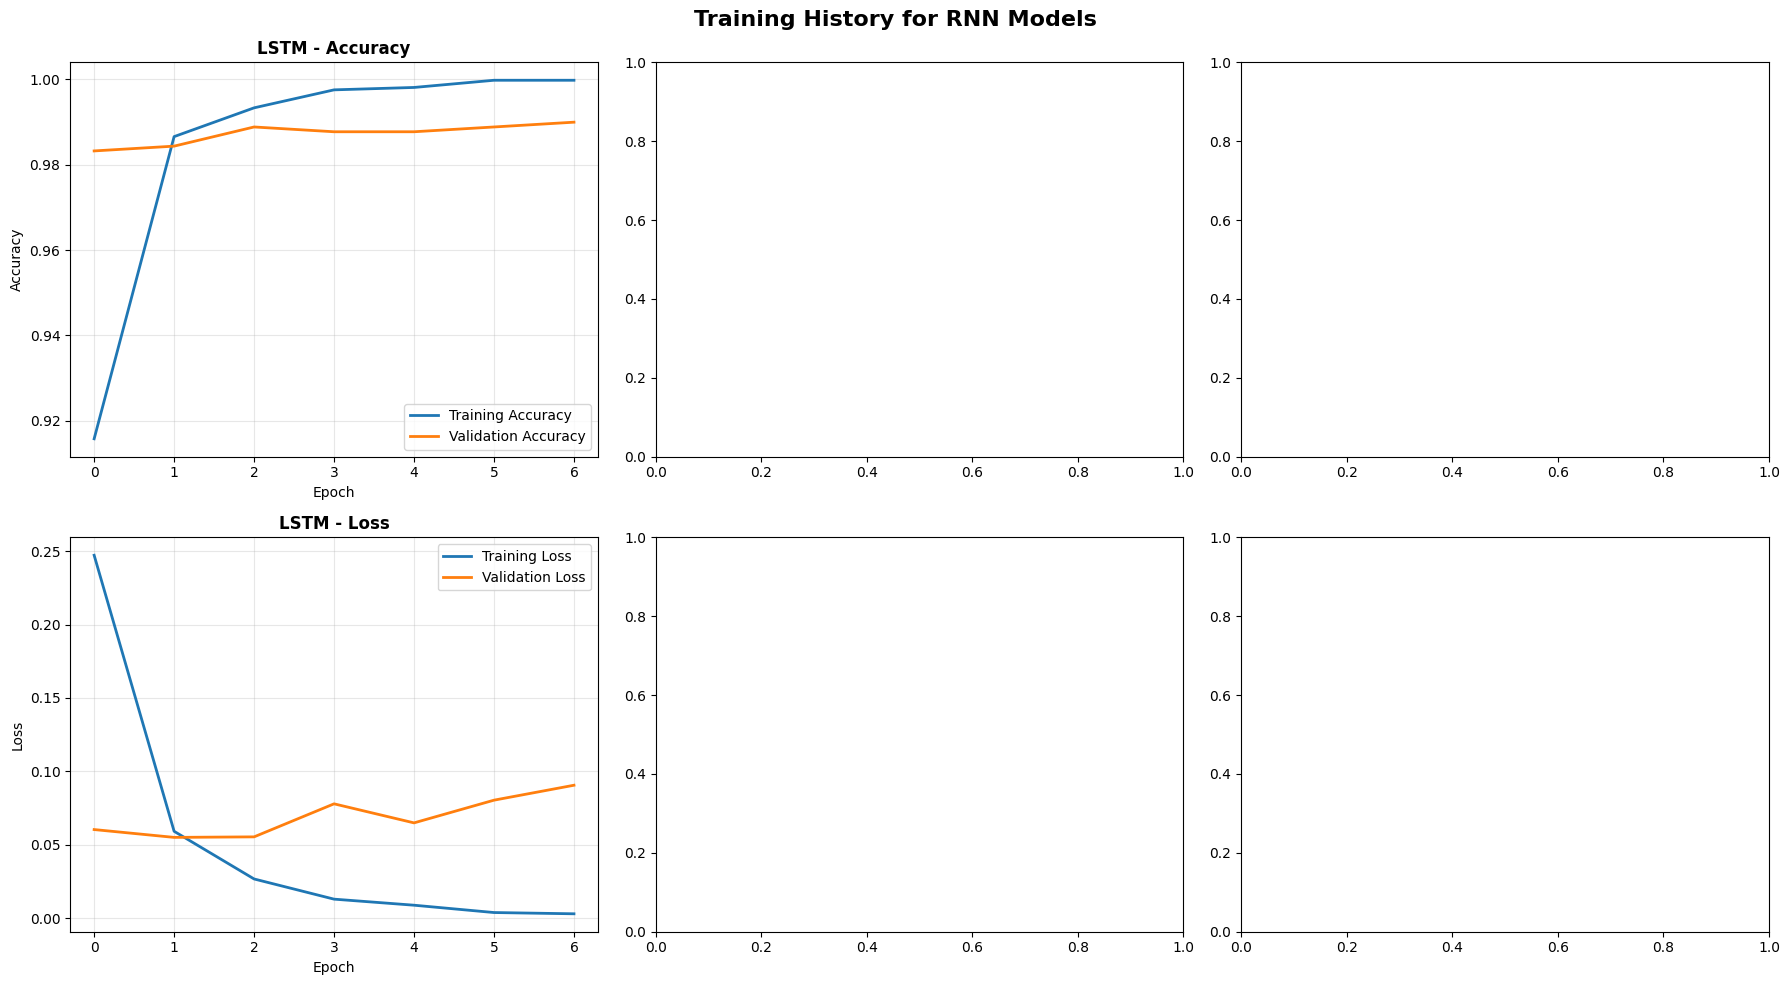

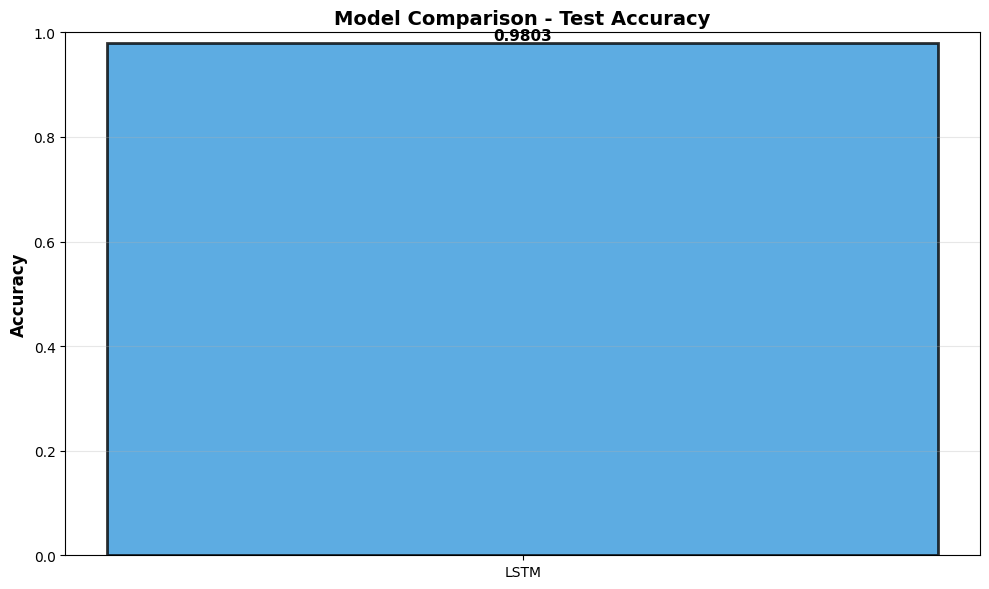

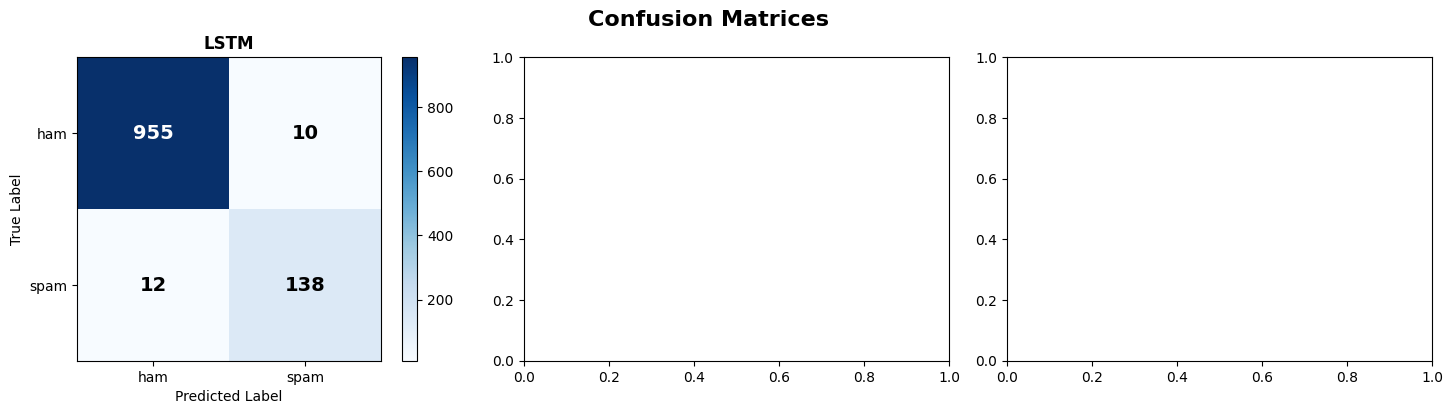

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,LSTM,Dropout,Bidirectional,Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Input
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings('ignore')
df=pd.read_csv('Spam_SMS.csv',encoding='latin-1')
print(df.head())
print(df.columns)
print(df.info())
df = df[['ï»¿Class', 'Message']]
df.columns = ['label', 'message']
label_counts = df['label'].value_counts()
print(label_counts)

# الاحتفاظ بالرموز المهمة (!, $, %) مع الحروف والمسافات
df['message'] = df['message'].str.replace(r"[^a-zA-Z\s!$%]", "", regex=True).str.lower()
df = df[df['message'].str.strip() != ""]

df['msg_length'] = df['message'].apply(len)
print(df['msg_length'].describe())

df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

X = df['message']
y = df['label_num']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)




max_words = 5000
max_len = 120
EMBEDDING_DIM = 128

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)


# تحويل النصوص إلى تسلسلات
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Padding
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

print(f"حجم القاموس: {len(tokenizer.word_index)}")
print(f"شكل بيانات التدريب: {X_train_pad.shape}")

# بناء نموذج LSTM
def build_lstm():
    """بناء نموذج LSTM"""
    model = Sequential([
        Input(shape=(max_len,)),
        Embedding(input_dim=max_words, output_dim=EMBEDDING_DIM, input_length=max_len),
        Bidirectional(LSTM(64, return_sequences=False   )),
        Dropout(0.5),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

EPOCHS = 20
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.2

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# قاموس لحفظ النماذج والنتائج
models = {}
histories = {}


class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)





print("\n--- تدريب LSTM ---")
model_lstm = build_lstm()
print(model_lstm.summary())

history_lstm = model_lstm.fit(
    X_train_pad, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    callbacks=[early_stop],
    verbose=1
)

models['LSTM'] = model_lstm
histories['LSTM'] = history_lstm


# ============================================
# 5. تقييم النماذج
# ============================================
print("\n[5] تقييم النماذج...")
print("="*70)

results = {}

for name, model in models.items():
    print(f"\n--- نتائج {name} ---")

    # التنبؤ
    
    y_pred_prob = model.predict(X_test_pad)
    threshold = 0.35

    y_pred = (y_pred_prob > threshold).astype(int).flatten()

    # حساب الدقة
    accuracy = accuracy_score(y_test, y_pred)

    # تقرير التصنيف
    print(f"\nDقة النموذج: {accuracy:.4f}")
    print("\nتقرير التصنيف:")
    print(classification_report(y_test, y_pred, target_names=['ham', 'spam']))

    # مصفوفة الارتباك
    cm = confusion_matrix(y_test, y_pred)
    print("\nمصفوفة الارتباك:")
    print(cm)
    # حفظ النتائج
    results[name] = {
        'accuracy': accuracy,
        'predictions': y_pred,
        'confusion_matrix': cm
    }    






# رسم منحنيات التدريب
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Training History for RNN Models', fontsize=16, fontweight='bold')

for idx, (name, history) in enumerate(histories.items()):
    # رسم الدقة
    axes[0, idx].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    if 'val_accuracy' in history.history:
        axes[0, idx].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    axes[0, idx].set_title(f'{name} - Accuracy', fontsize=12, fontweight='bold')
    axes[0, idx].set_xlabel('Epoch')
    axes[0, idx].set_ylabel('Accuracy')
    axes[0, idx].legend()
    axes[0, idx].grid(True, alpha=0.3)

    # رسم الخسارة
    axes[1, idx].plot(history.history['loss'], label='Training Loss', linewidth=2)
    if 'val_loss' in history.history:
        axes[1, idx].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[1, idx].set_title(f'{name} - Loss', fontsize=12, fontweight='bold')
    axes[1, idx].set_xlabel('Epoch')
    axes[1, idx].set_ylabel('Loss')
    axes[1, idx].legend()
    axes[1, idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
print("تم حفظ الرسم: training_history.png")

# رسم مقارنة الدقة
fig, ax = plt.subplots(figsize=(10, 6))
model_names = list(results.keys())
accuracies = [results[name]['accuracy'] for name in model_names]

bars = ax.bar(model_names, accuracies, color=['#3498db', '#e74c3c', '#2ecc71'], alpha=0.8, edgecolor='black', linewidth=2)
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Model Comparison - Test Accuracy', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1])
ax.grid(True, axis='y', alpha=0.3)

# إضافة القيم فوق الأعمدة
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
print("تم حفظ الرسم: model_comparison.png")

# رسم مصفوفات الارتباك
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Confusion Matrices', fontsize=16, fontweight='bold')

for idx, (name, result) in enumerate(results.items()):
    cm = result['confusion_matrix']
    im = axes[idx].imshow(cm, interpolation='nearest', cmap='Blues')
    axes[idx].set_title(f'{name}', fontsize=12, fontweight='bold')

    # إضافة colorbar
    plt.colorbar(im, ax=axes[idx])

    # إضافة التسميات
    axes[idx].set_xticks([0, 1])
    axes[idx].set_yticks([0, 1])
    axes[idx].set_xticklabels(['ham', 'spam'])
    axes[idx].set_yticklabels(['ham', 'spam'])
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

    # إضافة الأرقام داخل المصفوفة
    for i in range(2):
        for j in range(2):
            text = axes[idx].text(j, i, cm[i, j],
                                ha="center", va="center", color="white" if cm[i, j] > cm.max()/2 else "black",
                                fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
print("تم حفظ الرسم: confusion_matrices.png")

print("\nتم الانتهاء من جميع العمليات بنجاح.")

print("\n[7] اختبار النماذج على أمثلة جديدة...")
print("="*70)

test_sentences = [
    "This is an amazing and wonderful movie!",
    "Terrible film, waste of time and money.",
    "I absolutely loved it! Best movie ever!",
    "Boring and disappointing. Would not recommend.",
    "Great performances and excellent direction."
]

print("\nاختبار النماذج على جمل جديدة:\n")

for sentence in test_sentences:
    print(f"\nالجملة: {sentence}")

    # تحويل الجملة
    seq = tokenizer.texts_to_sequences([sentence])
    padded = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')

    # التنبؤ باستخدام كل نموذج
    for name, model in models.items():
        pred_prob = model.predict(padded, verbose=0)[0][0]
        sentiment = "spam" if pred_prob > 0.5 else "ham"
        print(f"  {name}: {sentiment} (احتمالية: {pred_prob:.4f})")

print("\n[7] اختبار النموذج على رسائل جديدة...")
print("="*70)

test_messages = [
    "Congratulations! You won a free iPhone. Click here now!",
    "Hey, are we meeting tomorrow at 5pm?",
    "URGENT! Your account has been suspended. Verify immediately.",
    "Can you send me the notes for today's lecture?",
    "WIN CASH NOW!!! Call this number to claim your prize."
]

print("\nاختبار النموذج على رسائل جديدة:\n")
for msg in test_messages:
    print(f"\nالرسالة: {msg}")
    msg_clean = ''.join([c.lower() for c in msg if c.isalpha() or c.isspace()])
    seq = tokenizer.texts_to_sequences([msg_clean])
    padded = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')
    
    pred_prob = model_lstm.predict(padded, verbose=0)[0][0]
    result = "spam" if pred_prob > threshold else "ham"  # استخدم threshold محسّن
    print(f"التصنيف: {result} (احتمالية: {pred_prob:.4f})")